# Xenofobia en redes sociales durante la pandemia de COVID-19 en Argentina
## Análisis para artículo en Revista PERIPLOS

**Autora:** Natalia De Bandi  
**Fecha:** Marzo 2026  

---

Este notebook forma parte de la investigación sobre discurso de odio xenofóbico en Twitter/X durante el período de pandemia (2020-2021) en Argentina. El análisis se enfoca en comentarios publicados en respuesta a noticias de medios de comunicación argentinos.

**Estructura del análisis:**
1. `periplos_1_dataset.ipynb` — Descripción y exploración del dataset (este notebook)
2. Próximos notebooks: análisis de xenofobia, evolución temporal, análisis por medio

## 1. Origen del dataset

### Fuente: Proyecto PIUBAMAS / HuggingFace

El dataset utilizado es `tweets_medios_arg.csv`, generado a partir del conjunto de datos público disponible en HuggingFace:

> **Dataset:** [`piubamas/articles_and_comments`](https://huggingface.co/datasets/piubamas/articles_and_comments)  
> **Proyecto:** PIUBAMAS (Programación UBA - Minería y Análisis de Sentimientos en Arabe y Español)

### ¿Qué contiene el dataset original?

El dataset de HuggingFace contiene **537.201 noticias** publicadas por cuentas de medios de comunicación en Twitter, junto con todos sus comentarios (respuestas). Cada comentario incluye predicciones de un clasificador de discurso de odio basado en el modelo BETO:

> **Clasificador:** [`piuba-bigdata/beto-contextualized-hate-speech`](https://huggingface.co/piuba-bigdata/beto-contextualized-hate-speech)

Las categorías de odio etiquetadas son:
| Etiqueta | Descripción |
|----------|-------------|
| `CALLS` | Llamados a la acción violenta |
| `WOMEN` | Odio hacia mujeres |
| `LGBTI` | Odio hacia personas LGBTI+ |
| `RACISM` | Racismo / xenofobia |
| `CLASS` | Odio por clase social |
| `POLITICS` | Odio político |
| `DISABLED` | Odio hacia personas con discapacidad |
| `APPEARANCE` | Odio por apariencia física |
| `CRIMINAL` | Estigmatización criminal |

### Proceso de construcción del subconjunto argentino

El notebook `1_create_ar_dataset.ipynb` recorta el dataset original para conservar únicamente los **comentarios a noticias publicadas por diarios argentinos**. El resultado se guarda en `data/tweets_medios_arg.csv`.

Los medios argentinos incluidos son:

| Usuario Twitter | Medio |
|-----------------|-------|
| `clarincom` | Clarín |
| `LANACION` | La Nación |
| `infobae` | Infobae |
| `pagina12` | Página 12 |
| `perfilcom` | Perfil |
| `cronica` | Crónica |
| `izquierdadiario` | La Izquierda Diario |
| `laderechadiario` | La Derecha Diario |
| `laderechamedios` | La Derecha Medios |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

## 2. Carga del dataset

In [2]:
df = pd.read_csv('data/tweets_medios_arg.csv', parse_dates=['date_tweet'])

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

Dataset cargado: 5,493,397 filas × 18 columnas


,id,tweet_id_noticia,title,resumen,medio,date_tweet,text,user_id,HATEFUL,CALLS,WOMEN,LGBTI,RACISM,CLASS,POLITICS,DISABLED,APPEARANCE,CRIMINAL
0,0,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:03:00.900,@clarincom A mi me preocupa el trabajo.. La ev...,1532596098,0,0,0,0,0,0,0,0,0,0
1,1,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:05:04.500,@clarincom Lo que preocupa. https://t.co/Vmf9V...,1222094021687943168,0,0,0,0,0,0,0,0,0,0
2,2,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:06:03.100,@clarincom Lo que les preocupa. https://t.co/P...,1222094021687943168,0,0,0,0,0,0,0,0,0,0
3,3,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:11:02.300,@clarincom Le recomendaríamos al presidente de...,582286194,0,0,0,0,0,0,0,0,0,0
4,4,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:26:00.600,@clarincom Para salvar al correo de la quiebra...,951552761988034560,0,0,0,0,0,0,0,0,0,0


## 3. Descripción del dataset

### 3.1 Estructura de columnas

In [3]:
# Descripción de columnas y tipos de datos
col_desc = {
    'id': 'Índice del comentario dentro de la noticia',
    'tweet_id_noticia': 'ID del tweet de la noticia a la que responde el comentario',
    'title': 'Título de la noticia',
    'resumen': 'Texto del tweet de la noticia (resumen)',
    'medio': 'Cuenta de Twitter del medio de comunicación',
    'date_tweet': 'Fecha y hora del comentario (UTC)',
    'text': 'Texto del comentario',
    'user_id': 'ID del usuario que publicó el comentario',
    'HATEFUL': 'Indicador agregado: 1 si el comentario fue clasificado como odioso en alguna categoría',
    'CALLS': 'Llamados a la violencia',
    'WOMEN': 'Odio hacia mujeres',
    'LGBTI': 'Odio hacia LGBTI+',
    'RACISM': 'Racismo / xenofobia',
    'CLASS': 'Odio por clase social',
    'POLITICS': 'Odio político',
    'DISABLED': 'Odio hacia personas con discapacidad',
    'APPEARANCE': 'Odio por apariencia física',
    'CRIMINAL': 'Estigmatización criminal',
}

desc_df = pd.DataFrame({
    'Columna': col_desc.keys(),
    'Descripción': col_desc.values(),
    'Tipo': [df[c].dtype for c in col_desc.keys()]
})
display(desc_df)

,Columna,Descripción,Tipo
0,id,Índice del comentario dentro de la noticia,int64
1,tweet_id_noticia,ID del tweet de la noticia a la que responde e...,int64
2,title,Título de la noticia,str
3,resumen,Texto del tweet de la noticia (resumen),str
4,medio,Cuenta de Twitter del medio de comunicación,str
5,date_tweet,Fecha y hora del comentario (UTC),datetime64[us]
6,text,Texto del comentario,str
7,user_id,ID del usuario que publicó el comentario,int64
8,HATEFUL,Indicador agregado: 1 si el comentario fue cla...,int64
9,CALLS,Llamados a la violencia,int64


### 3.2 Estadísticas generales

In [4]:
print("=" * 55)
print("ESTADÍSTICAS GENERALES DEL DATASET")
print("=" * 55)
print(f"  Total de comentarios:      {len(df):>12,}")
print(f"  Comentarios odiosos:       {df['HATEFUL'].sum():>12,}  ({df['HATEFUL'].mean()*100:.1f}%)")
print(f"  Comentarios no odiosos:    {(df['HATEFUL']==0).sum():>12,}  ({(df['HATEFUL']==0).mean()*100:.1f}%)")
print(f"  Rango temporal:            {df['date_tweet'].min().date()} → {df['date_tweet'].max().date()}")
print(f"  Medios cubiertos:          {df['medio'].nunique():>12,}")
print(f"  Noticias únicas:           {df['tweet_id_noticia'].nunique():>12,}")
print(f"  Usuarios únicos:           {df['user_id'].nunique():>12,}")

ESTADÍSTICAS GENERALES DEL DATASET
  Total de comentarios:         5,493,397
  Comentarios odiosos:            340,593  (6.2%)
  Comentarios no odiosos:       5,152,804  (93.8%)
  Rango temporal:            2020-02-10 → 2021-06-25
  Medios cubiertos:                     9
  Noticias únicas:                330,600
  Usuarios únicos:                402,870


### 3.3 Distribución por medio de comunicación

In [5]:
medios_stats = df.groupby('medio').agg(
    comentarios=('text', 'count'),
    odiosos=('HATEFUL', 'sum'),
    noticias=('tweet_id_noticia', 'nunique'),
    primer_tweet=('date_tweet', 'min'),
    ultimo_tweet=('date_tweet', 'max')
).sort_values('comentarios', ascending=False)

medios_stats['% odio'] = (medios_stats['odiosos'] / medios_stats['comentarios'] * 100).round(2)
medios_stats['primer_tweet'] = medios_stats['primer_tweet'].dt.date
medios_stats['ultimo_tweet'] = medios_stats['ultimo_tweet'].dt.date

display(medios_stats[['comentarios', 'noticias', 'odiosos', '% odio', 'primer_tweet', 'ultimo_tweet']])

,comentarios,noticias,odiosos,% odio,primer_tweet,ultimo_tweet
medio,,,,,,
infobae,1691830,98751,105128,6.21,2020-02-10,2021-06-25
LANACION,1574297,51536,94459,6.00,2020-02-10,2021-06-25
clarincom,1486018,66267,96918,6.52,2020-02-10,2021-06-25
pagina12,221971,29184,10242,4.61,2020-02-13,2021-06-25
cronica,205588,50316,15371,7.48,2020-02-10,2021-06-24
perfilcom,159860,21056,7237,4.53,2020-02-10,2021-06-25
laderechamedios,69944,2800,4726,6.76,2020-07-14,2021-02-26
laderechadiario,65907,2904,4869,7.39,2020-02-11,2021-06-24
izquierdadiario,17982,7786,1643,9.14,2020-03-06,2021-06-22


### 3.4 Cobertura temporal del dataset

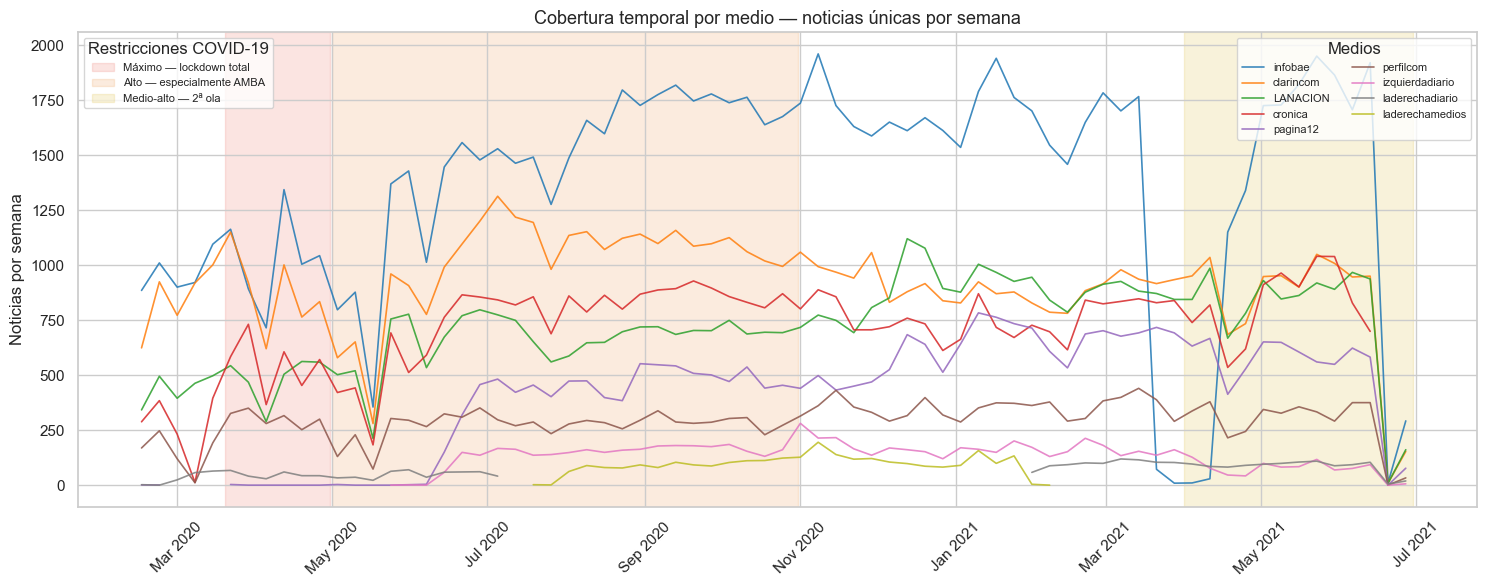

In [6]:
import matplotlib.dates as mdates

# --- Noticias únicas por SEMANA y por medio ---
df_noticias = df.drop_duplicates(subset=['tweet_id_noticia', 'medio']).copy()

noticias_semanales = (
    df_noticias
    .groupby(['medio', pd.Grouper(key='date_tweet', freq='W')])['tweet_id_noticia']
    .count()
    .unstack('medio')
)

# Rango completo semanal → NaN donde no hay datos (rompe la línea)
semana_rango = pd.date_range(noticias_semanales.index.min(), noticias_semanales.index.max(), freq='W')
noticias_semanales = noticias_semanales.reindex(semana_rango)

# Reemplazar 0 por NaN también (semanas con cero noticias = hueco)
noticias_semanales = noticias_semanales.replace(0, float('nan'))

# Orden por volumen total
orden_medios = noticias_semanales.sum().sort_values(ascending=False).index.tolist()

# --- Períodos de restricciones ---
periodos = [
    (pd.Timestamp('2020-03-20'), pd.Timestamp('2020-04-30'), '#e74c3c', 'Máximo — lockdown total'),
    (pd.Timestamp('2020-05-01'), pd.Timestamp('2020-10-31'), '#e67e22', 'Alto — especialmente AMBA'),
    (pd.Timestamp('2021-04-01'), pd.Timestamp('2021-06-30'), '#d4ac0d', 'Medio-alto — 2ª ola'),
]

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(15, 6))

# Franjas de pandemia (fondo)
franja_handles = []
for inicio, fin, color, label in periodos:
    patch = ax.axvspan(inicio, fin, alpha=0.15, color=color, zorder=0, label=label)
    franja_handles.append(patch)

# Líneas por medio
colores = plt.cm.tab10.colors
linea_handles = []
for i, medio in enumerate(orden_medios):
    serie = noticias_semanales[medio]
    linea, = ax.plot(serie.index, serie.values,
                     label=medio, color=colores[i % len(colores)],
                     linewidth=1.2, alpha=0.85)
    linea_handles.append(linea)

# Ejes y formato
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.set_ylabel('Noticias por semana')
ax.set_title('Cobertura temporal por medio — noticias únicas por semana', fontsize=13)

# Dos leyendas separadas
ley_medios = ax.legend(handles=linea_handles, loc='upper right', fontsize=8,
                       title='Medios', ncol=2)
ax.add_artist(ley_medios)
ax.legend(handles=franja_handles, loc='upper left', fontsize=8,
          title='Restricciones COVID-19')

plt.tight_layout()
plt.savefig('outputs/cobertura_temporal_medios.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
import html as htmllib
from IPython.display import display, HTML

# ── Selección de noticia representativa (top en comentarios RACISM) ──────────
candidatas = (
    df[df['RACISM'] == 1]
    .groupby(['tweet_id_noticia', 'medio', 'title', 'resumen'])
    .size()
    .reset_index(name='n_racism')
    .query('n_racism >= 5')
    .sort_values('n_racism', ascending=False)
)

# Índice 2 para tener variedad (cambiar por 0, 1, 3... para ver otras noticias)
row = candidatas.iloc[2]
tweet_id  = row['tweet_id_noticia']
medio     = row['medio']
titulo    = htmllib.escape(str(row['title']))
resumen   = htmllib.escape(str(row['resumen'])[:300])

todos = df[df['tweet_id_noticia'] == tweet_id].copy()
fecha_str         = todos['date_tweet'].min().strftime('%d %b %Y')
total_comentarios = len(todos)
n_racism          = row['n_racism']

# 4 comentarios con RACISM=1
odiosos = todos[todos['RACISM'] == 1].head(4)

url_tweet = f"https://twitter.com/{medio}/status/{tweet_id}"

# ── Badges de categorías ─────────────────────────────────────────────────────
CATEGORIAS = {
    'RACISM':     ('#c0392b', 'Xenofobia / Racismo'),
    'CALLS':      ('#922b21', 'Llamado a violencia'),
    'WOMEN':      ('#884ea0', 'Odio a mujeres'),
    'LGBTI':      ('#1a5276', 'Odio LGBTI+'),
    'CLASS':      ('#1e8449', 'Odio por clase social'),
    'POLITICS':   ('#d4ac0d', 'Odio político'),
    'DISABLED':   ('#2471a3', 'Odio a discapacidad'),
    'APPEARANCE': ('#ca6f1e', 'Odio por apariencia'),
    'CRIMINAL':   ('#5d6d7e', 'Estigma criminal'),
}

def make_badges(c_row):
    badges = ''
    for col, (color, label) in CATEGORIAS.items():
        if c_row.get(col, 0) == 1:
            badges += (f'<span style="background:{color};color:white;'
                       f'padding:2px 8px;border-radius:10px;font-size:11px;'
                       f'margin-right:4px;">{label}</span>')
    return badges or '<span style="color:#aaa;font-size:11px;">sin etiqueta</span>'

# ── Nombres legibles de medios ────────────────────────────────────────────────
NOMBRES = {
    'clarincom': 'Clarín', 'LANACION': 'La Nación', 'infobae': 'Infobae',
    'pagina12': 'Página 12', 'cronica': 'Crónica', 'perfilcom': 'Perfil',
    'laderechamedios': 'La Derecha Medios', 'laderechadiario': 'La Derecha Diario',
    'izquierdadiario': 'Izquierda Diario',
}
nombre_medio = NOMBRES.get(medio, medio)

# ── Bloque de comentarios ─────────────────────────────────────────────────────
comentarios_html = ''
for _, c in odiosos.iterrows():
    texto  = htmllib.escape(str(c['text'])[:280])
    fecha_c = c['date_tweet'].strftime('%d %b %Y %H:%M')
    comentarios_html += f"""
    <div style="margin:10px 0 10px 36px; padding:12px 15px; background:#fff;
                border-left:3px solid #e74c3c; border-radius:6px;
                box-shadow:0 1px 3px rgba(0,0,0,0.08);">
      <div style="font-size:12px; color:#888; margin-bottom:6px;">
        💬 Usuario anónimo · {fecha_c}
      </div>
      <div style="font-size:14px; color:#222; line-height:1.6;">
        {texto}
      </div>
      <div style="margin-top:8px;">
        {make_badges(c)}
      </div>
    </div>"""

# ── HTML final ────────────────────────────────────────────────────────────────
html = f"""
<div style="font-family:'Segoe UI',Arial,sans-serif; max-width:700px; margin:20px auto;">

  <!-- Encabezado explicativo -->
  <div style="background:#e8f4fd; border-radius:8px; padding:10px 16px;
              margin-bottom:16px; font-size:13px; color:#2471a3; line-height:1.6;">
    <strong>Estructura del dataset</strong><br>
    Cada fila representa un <em>comentario</em> asociado a una <em>noticia</em> publicada
    por un medio en Twitter/X. Esta noticia recibió
    <strong>{total_comentarios:,} comentarios</strong>,
    de los cuales <strong>{n_racism} fueron clasificados como xenofobia/racismo</strong>.
    Se muestran 4 a modo de ejemplo.
  </div>

  <!-- Tweet del medio (noticia) -->
  <div style="background:#f7f9fa; border:1px solid #dce1e7; border-radius:12px;
              padding:18px 20px;">

    <!-- Cabecera usuario -->
    <div style="display:flex; align-items:center; margin-bottom:12px;">
      <div style="width:42px; height:42px; background:#1da1f2; border-radius:50%;
                  display:flex; align-items:center; justify-content:center;
                  color:white; font-weight:bold; font-size:17px; margin-right:12px;
                  flex-shrink:0;">
        {nombre_medio[0]}
      </div>
      <div>
        <div style="font-weight:700; font-size:14px; color:#14171a;">{nombre_medio}</div>
        <div style="font-size:12px; color:#657786;">@{medio} · {fecha_str}</div>
      </div>
      <div style="margin-left:auto;">
        <span style="background:#1da1f2; color:white; font-size:11px;
                     padding:3px 9px; border-radius:12px;">NOTICIA</span>
      </div>
    </div>

    <!-- Texto del tweet -->
    <div style="font-size:15px; color:#14171a; line-height:1.65; margin-bottom:12px;">
      {resumen}
    </div>

    <!-- Card título noticia -->
    <div style="border:1px solid #dce1e7; border-radius:10px; padding:12px 15px;
                background:white; margin-bottom:12px;">
      <div style="font-size:10px; color:#aaa; text-transform:uppercase;
                  letter-spacing:.5px; margin-bottom:5px;">Título</div>
      <div style="font-size:14px; font-weight:600; color:#14171a; line-height:1.45;">
        {titulo}
      </div>
    </div>

    <!-- Enlace -->
    <div style="font-size:13px;">
      <a href="{url_tweet}" target="_blank"
         style="color:#1da1f2; text-decoration:none;">
        🔗 Ver tweet original en Twitter/X →
      </a>
    </div>
  </div>

  <!-- Separador de hilo -->
  <div style="margin:8px 0 4px 18px; color:#aaa; font-size:12px;">
    ↳ {total_comentarios:,} respuestas en total —
    mostrando {len(odiosos)} clasificadas como xenofobia/racismo
  </div>

  <!-- Comentarios -->
  {comentarios_html}

</div>
"""

display(HTML(html))


## 4. Filtrado por palabras clave: DNU y seguridad migratoria

Para el análisis específico sobre el DNU de extranjeros, se filtra el dataset completo conservando únicamente aquellas filas donde el **título de la noticia** (`title`), el **tweet del medio** (`resumen`) o el **comentario** (`text`) contengan al menos una de las siguientes palabras clave:

| Palabra clave | Justificación |
|---|---|
| `DNU` | Decreto de Necesidad y Urgencia sobre migrantes (enero 2017) |
| `extranjeros` | Término central del decreto y del debate público |
| `antecedentes` | Requisito de antecedentes penales incorporado por el DNU |
| `expulsión` | Mecanismo de deportación habilitado por el decreto |
| `delincuente` | Estigma criminal asociado a la población migrante |

La búsqueda es **insensible a mayúsculas/minúsculas** y no requiere coincidencia exacta de acentos (se normaliza antes de buscar). Se busca en los tres campos simultáneamente con `OR`.

In [8]:
import unicodedata

def normalizar(texto):
    """Minúsculas y sin tildes para búsqueda robusta."""
    if not isinstance(texto, str):
        return ''
    texto = texto.lower()
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    return texto

KEYWORDS = ['dnu', 'extranjeros', 'antecedentes', 'expulsion', 'delincuente']

# Normalizar los tres campos de texto
for col in ['title', 'resumen', 'text']:
    df[f'_{col}_norm'] = df[col].apply(normalizar)

# Máscara: al menos una keyword en alguno de los tres campos
mascara = df[['_title_norm', '_resumen_norm', '_text_norm']].apply(
    lambda col: col.str.contains('|'.join(KEYWORDS), regex=True)
).any(axis=1)

df_dnu = df[mascara].drop(columns=['_title_norm', '_resumen_norm', '_text_norm']).copy()

# Limpiar columnas temporales del df original
df.drop(columns=['_title_norm', '_resumen_norm', '_text_norm'], inplace=True)

print(f"Filas totales:          {len(df):>10,}")
print(f"Filas filtradas (DNU):  {len(df_dnu):>10,}  ({len(df_dnu)/len(df)*100:.2f}%)")
print()
print("Distribución por medio:")
display(
    df_dnu.groupby('medio').agg(
        comentarios=('text', 'count'),
        odiosos=('HATEFUL', 'sum')
    ).assign(**{'% odio': lambda x: (x['odiosos'] / x['comentarios'] * 100).round(2)})
    .sort_values('comentarios', ascending=False)
)

# Guardar subconjunto
df_dnu.to_csv('data/piubamas_dnu_keywords.csv', index=False)
print("\nGuardado en: data/piubamas_dnu_keywords.csv")

Filas totales:           5,493,397
Filas filtradas (DNU):      98,514  (1.79%)

Distribución por medio:


,comentarios,odiosos,% odio
medio,,,
infobae,30807,3321,10.78
clarincom,28169,3107,11.03
LANACION,27506,2520,9.16
cronica,3502,732,20.90
perfilcom,3206,261,8.14
pagina12,3133,264,8.43
laderechamedios,1140,95,8.33
laderechadiario,819,99,12.09
izquierdadiario,232,50,21.55



Guardado en: data/piubamas_dnu_keywords.csv
